ΠΕΤΡΟΥΛΑ ΤΣΙΜΠΙΝΗ - ics23085



In [ ]:
#Εγκατάσταση PySpark στο Google Colab
!pip install pyspark

In [ ]:
#Εισαγωγή απαραίτητων βιβλιοθηκών
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import FloatType, IntegerType
from pyspark.ml.feature import Imputer

In [ ]:

#Δημιουργία Dataframe και αρχικοποίηση SparkSession
spark = SparkSession.builder \
    .appName("TelecomChurnAnalysis") \
    .getOrCreate()

In [ ]:
from google.colab import files
import io

#Ανέβασμα του αρχείου
print("Παρακαλώ επιλέξτε το αρχείο telecom_churn_10k.csv:")
uploaded = files.upload()

#Λήψη του ονόματος του αρχείου που ανέβηκε
file_name = list(uploaded.keys())[0]

#Φόρτωση στο Spark DataFrame
df = spark.read.csv(file_name, header=True, inferSchema=True)

#Επιβεβαίωση
print(f"Το αρχείο {file_name} φορτώθηκε επιτυχώς στο Spark DataFrame.")

Παρακαλώ επιλέξτε το αρχείο telecom_churn_10k.csv:


Saving telecom_churn_10k.csv to telecom_churn_10k.csv
Το αρχείο telecom_churn_10k.csv φορτώθηκε επιτυχώς στο Spark DataFrame.


In [ ]:
# Εμφάνιση των πρώτων 10 γραμμών
print("Πρώτες 10 γραμμές του DataFrame:")
df.show(10)

#Εμφάνιση του σχήματος
print("Σχήμα των δεδομένων:")
df.printSchema()

# Συνολικός αριθμός εγγραφών
print(f"Συνολικός αριθμός εγγραφών: {df.count()}")

Πρώτες 10 γραμμές του DataFrame:
+-----------+------+----+-------+-------------+--------------+------------+----------+------+---------------+-------------+--------------+-------------+--------------+-----+
|CUSTOMER_ID|GENDER| AGE|COUNTRY|TENURE_MONTHS| CONTRACT_TYPE|HAS_INTERNET|HAS_MOBILE|HAS_TV|MONTHLY_CHARGES|TOTAL_CHARGES|NUM_COMPLAINTS|SUPPORT_CALLS|PAYMENT_METHOD|CHURN|
+-----------+------+----+-------+-------------+--------------+------------+----------+------+---------------+-------------+--------------+-------------+--------------+-----+
|    C000001|  Male|68.0|     FR|         61.0|Month-to-month|           0|         1|     0|          17.54|      1077.63|             0|            0| Bank transfer|  1.0|
|    C000002|Female|65.0|     FR|         NULL|Month-to-month|           1|         1|     0|          50.82|       833.94|             1|            1|   Credit card|  0.0|
|    C000003|  Male|36.0|     FR|         53.0|      Two year|           1|         1|     0|    

In [ ]:
# Έλεγχος ελλιπών τιμών
print("\n--- Έλεγχος ελλιπών τιμών ανά στήλη ---")

# Ορισμός των αριθμητικών στηλών δυναμικά
numeric_cols = [name for name, dtype in df.dtypes if dtype in ["int", "double", "float", "long"]]

# Παρουσίαση συγκεντρωτικά (column_name, missing_count)
missing_counts_data = []
for c in df.columns:
    if c in numeric_cols:
        count = df.filter(F.col(c).isNull() | F.isnan(F.col(c))).count()
    else:
        count = df.filter(F.col(c).isNull()).count()
    missing_counts_data.append((c, count))

missing_counts_df = spark.createDataFrame(missing_counts_data, ["column_name", "missing_count"])
missing_counts_df.show()

"""
Σχόλιο:Το CHURN επηρεάζει περισσότερο την ανάλυση καθώς αποτελεί τη μεταβλητή-στόχο για το μοντέλο πρόβλεψης.
Τα πεδία TENURE_MONTHS και TOTAL_CHARGES ακολουθούν σε σημασία καθώς προσδιορίζουν την πιστότητα και την αξία του πελάτη.
Τα πεδία MONTHLY_CHARGES και AGE αν και είναι σημαντικά, η απουσία τους ίσως μπορεί  να αναπληρωθεί π.χ. με τη μέση τιμή αλλά το CHURN παραμένει το πιο κρίσιμο για την ακεραιότητα της πρόβλεψης.
Ελλιπείς τιμές σε αυτά τα κρίσιμα πεδία εμποδίζουν την ορθή εκπαίδευση του αλγορίθμου και μειώνουν την αξιοπιστία των συμπερασμάτων.
"""


--- Έλεγχος ελλιπών τιμών ανά στήλη ---
+---------------+-------------+
|    column_name|missing_count|
+---------------+-------------+
|    CUSTOMER_ID|            0|
|         GENDER|            0|
|            AGE|          300|
|        COUNTRY|            0|
|  TENURE_MONTHS|          300|
|  CONTRACT_TYPE|            0|
|   HAS_INTERNET|            0|
|     HAS_MOBILE|            0|
|         HAS_TV|            0|
|MONTHLY_CHARGES|          300|
|  TOTAL_CHARGES|          300|
| NUM_COMPLAINTS|            0|
|  SUPPORT_CALLS|            0|
| PAYMENT_METHOD|            0|
|          CHURN|          300|
+---------------+-------------+



'\nΣχόλιο:Το CHURN επηρεάζει περισσότερο την ανάλυση καθώς αποτελεί τη μεταβλητή-στόχο για το μοντέλο πρόβλεψης.\nΤα πεδία TENURE_MONTHS και TOTAL_CHARGES ακολουθούν σε σημασία καθώς προσδιορίζουν την πιστότητα και την αξία του πελάτη.\nΤα πεδία MONTHLY_CHARGES και AGE αν και είναι σημαντικά, η απουσία τους ίσως μπορεί  να αναπληρωθεί π.χ. με τη μέση τιμή αλλά το CHURN παραμένει το πιο κρίσιμο για την ακεραιότητα της πρόβλεψης.\nΕλλιπείς τιμές σε αυτά τα κρίσιμα πεδία εμποδίζουν την ορθή εκπαίδευση του αλγορίθμου και μειώνουν την αξιοπιστία των συμπερασμάτων.\n'

In [ ]:

from pyspark.sql import functions as F

#  Αφαίρεση γραμμών όπου το CHURN είναι null
df_cleaned = df.dropna(subset=["CHURN"])

# Συμπλήρωση ελλιπών τιμών για AGE, TENURE_MONTHS και MONTHLY_CHARGES με το μέσο όρο
# Χρειαζόμαστε αυτές τις τιμές για να υπολογίσουμε σωστά το TOTAL_CHARGES
imputer = Imputer(
    inputCols=["AGE", "TENURE_MONTHS", "MONTHLY_CHARGES"],
    outputCols=["AGE", "TENURE_MONTHS", "MONTHLY_CHARGES"],
    strategy="mean"
)
df_cleaned = imputer.fit(df_cleaned).transform(df_cleaned)

# Αν το TOTAL_CHARGES λείπει το υπολογίζουμε ως: MONTHLY_CHARGES * TENURE_MONTHS
df_cleaned = df_cleaned.withColumn(
    "TOTAL_CHARGES",
    F.when(
        F.col("TOTAL_CHARGES").isNull() | F.isnan(F.col("TOTAL_CHARGES")),
        F.col("MONTHLY_CHARGES") * F.col("TENURE_MONTHS")
    ).otherwise(F.col("TOTAL_CHARGES"))
)

# Αν παρόλα αυτά υπάρχουν ακόμα null (π.χ. αν κάποιος είχε Tenure=0) συμπληρώνουμε με το γενικό μέσο όρο
total_charges_mean = df_cleaned.select(F.mean("TOTAL_CHARGES")).collect()[0][0]
df_cleaned = df_cleaned.fillna({"TOTAL_CHARGES": total_charges_mean})

df_cleaned.select([F.count(F.when(F.col(c).isNull() | F.isnan(F.col(c)), c)).alias(c)
                   for c in ["CHURN", "AGE", "TENURE_MONTHS", "MONTHLY_CHARGES", "TOTAL_CHARGES"]]).show()

"""Σχολιασμός Στρατηγικής: Διαγραφή null στο CHURN  και συμπλήρωση AGE,TENURE_MONTHS και MONTHLY_CHARGES με μέσο όρο.
   Στο TOTAL_CHARGES χρησιμοποιήθηκε ο τύπος MONTHLY_CHARGES * TENURE_MONTHS για
   ρεαλιστικότερη αποτύπωση των δεδομένων και μεγαλύτερη ακρίβεια στο μοντέλο."""


+-----+---+-------------+---------------+-------------+
|CHURN|AGE|TENURE_MONTHS|MONTHLY_CHARGES|TOTAL_CHARGES|
+-----+---+-------------+---------------+-------------+
|    0|  0|            0|              0|            0|
+-----+---+-------------+---------------+-------------+



'Σχολιασμός Στρατηγικής: Διαγραφή null στο CHURN  και συμπλήρωση AGE,TENURE_MONTHS και MONTHLY_CHARGES με μέσο όρο.\n   Στο TOTAL_CHARGES χρησιμοποιήθηκε ο τύπος MONTHLY_CHARGES * TENURE_MONTHS για\n   ρεαλιστικότερη αποτύπωση των δεδομένων και μεγαλύτερη ακρίβεια στο μοντέλο.'

In [ ]:
# Βασική περιγραφική ανάλυση
print("\n--- Βασικά στατιστικά (Describe) ---")
df_cleaned.select("AGE", "TENURE_MONTHS", "MONTHLY_CHARGES", "TOTAL_CHARGES").describe().show()

# Μέσος όρος TENURE και MONTHLY_CHARGES ανά CHURN
print("Μέσοι όροι ανά κατάσταση Churn (0 = Παραμονή, 1 = Αποχώρηση):")
df_cleaned.groupBy("CHURN").agg(
    F.avg("TENURE_MONTHS").alias("Avg_Tenure"),
    F.avg("MONTHLY_CHARGES").alias("Avg_Monthly_Charges")
).show()

"""
Σχολιασμός:
Οι πελάτες που αποχωρούν (CHURN=1) παρουσιάζουν μικρότερη μέση διάρκεια παραμονής (tenure) σε σχέση με όσους παραμένουν,
γεγονός που υποδηλώνει μειωμένη δέσμευση στην υπηρεσία. Παράλληλα, οι μέσες μηνιαίες χρεώσεις είναι ελαφρώς υψηλότερες
στην ομάδα των πελατών που αποχωρούν, κάτι που ενδέχεται να λειτουργεί αποτρεπτικά. Το εύρημα αυτό δείχνει ότι τόσο η
διάρκεια συνεργασίας όσο και το κόστος αποτελούν σημαντικούς παράγοντες πρόβλεψης churn.
"""


--- Βασικά στατιστικά (Describe) ---
+-------+------------------+------------------+------------------+------------------+
|summary|               AGE|     TENURE_MONTHS|   MONTHLY_CHARGES|     TOTAL_CHARGES|
+-------+------------------+------------------+------------------+------------------+
|  count|              9700|              9700|              9700|              9700|
|   mean| 51.42650653629523|36.559855411439315|36.556964285714315|1337.0745351492799|
| stddev|19.247481813671897|20.466005655823807|11.127497787046334| 887.3388774541093|
|    min|              18.0|               1.0|               5.0|               0.0|
|    max|              85.0|              72.0|             80.45|           5197.62|
+-------+------------------+------------------+------------------+------------------+

Μέσοι όροι ανά κατάσταση Churn (0 = Παραμονή, 1 = Αποχώρηση):
+-----+------------------+-------------------+
|CHURN|        Avg_Tenure|Avg_Monthly_Charges|
+-----+------------------+-----

'\nΣχολιασμός:\nΟι πελάτες που αποχωρούν (CHURN=1) παρουσιάζουν μικρότερη μέση διάρκεια παραμονής (tenure) σε σχέση με όσους παραμένουν,\nγεγονός που υποδηλώνει μειωμένη δέσμευση στην υπηρεσία. Παράλληλα, οι μέσες μηνιαίες χρεώσεις είναι ελαφρώς υψηλότερες\nστην ομάδα των πελατών που αποχωρούν, κάτι που ενδέχεται να λειτουργεί αποτρεπτικά. Το εύρημα αυτό δείχνει ότι τόσο η\nδιάρκεια συνεργασίας όσο και το κόστος αποτελούν σημαντικούς παράγοντες πρόβλεψης churn.\n'

In [ ]:
# Αρχικό Feature Engineering
# Δημιουργία NUM_SERVICES
# Δημιουργία IS_LONG_TENURE
# Δημιουργία AVG_CHARGE_PER_MONTH

df_final = df_cleaned.withColumn("NUM_SERVICES", F.col("HAS_INTERNET") + F.col("HAS_MOBILE") + F.col("HAS_TV")) \
                     .withColumn("IS_LONG_TENURE", F.when(F.col("TENURE_MONTHS") >= 24, 1).otherwise(0)) \
                     .withColumn("AVG_CHARGE_PER_MONTH",
                                 F.when(F.col("TENURE_MONTHS") > 0, F.col("TOTAL_CHARGES") / F.col("TENURE_MONTHS"))
                                 .otherwise(F.col("MONTHLY_CHARGES")))

# Εμφάνιση δείγματος με τις νέες στήλες
print("\n--- Δείγμα DataFrame με τα νέα πεδία (Feature Engineering) ---")
df_final.select("CUSTOMER_ID", "TENURE_MONTHS", "NUM_SERVICES", "IS_LONG_TENURE", "AVG_CHARGE_PER_MONTH").show(10)


--- Δείγμα DataFrame με τα νέα πεδία (Feature Engineering) ---
+-----------+-----------------+------------+--------------+--------------------+
|CUSTOMER_ID|    TENURE_MONTHS|NUM_SERVICES|IS_LONG_TENURE|AVG_CHARGE_PER_MONTH|
+-----------+-----------------+------------+--------------+--------------------+
|    C000001|             61.0|           1|             1|  17.666065573770492|
|    C000002|36.55985541143951|           2|             1|   22.81026526541081|
|    C000003|             53.0|           2|             1|                34.5|
|    C000004|              6.0|           3|             0|               45.26|
|    C000005|             39.0|           3|             1|  38.953589743589745|
|    C000006|             25.0|           3|             1|             57.7488|
|    C000007|             42.0|           2|             1|   47.51690476190476|
|    C000008|             42.0|           2|             1|  29.615476190476187|
|    C000009|             59.0|           1| 

In [ ]:
#Δημιουργία προσωρινού view από το καθαρισμένο DataFrame
df_final.createOrReplaceTempView("churn_view")

In [ ]:
# ερωτήματα ανάλυσης churn

# 2.1Churn ανά τύπο συμβολαίου
print("2.1. Churn ανά τύπο συμβολαίου:")
query_21 = """
SELECT
    CONTRACT_TYPE,
    COUNT(*) AS Total_Customers,
    SUM(CASE WHEN CHURN = 1 THEN 1 ELSE 0 END) AS Churn_Count,
    ROUND(
        (SUM(CASE WHEN CHURN = 1 THEN 1 ELSE 0 END) / COUNT(*)) * 100,
        2
    ) AS Churn_Percentage
FROM churn_view
GROUP BY CONTRACT_TYPE
ORDER BY Churn_Percentage DESC
"""
spark.sql(query_21).show()

2.1. Churn ανά τύπο συμβολαίου:
+--------------+---------------+-----------+----------------+
| CONTRACT_TYPE|Total_Customers|Churn_Count|Churn_Percentage|
+--------------+---------------+-----------+----------------+
|Month-to-month|           5326|       2834|           53.21|
|      One year|           2440|        503|           20.61|
|      Two year|           1934|        264|           13.65|
+--------------+---------------+-----------+----------------+



In [ ]:
# 2.2 Churn ανά πλήθος υπηρεσιών
print("2.2. Churn ανά πλήθος υπηρεσιών (1, 2, >=3):")
query_22 = """
SELECT
    CASE
        WHEN NUM_SERVICES >= 3 THEN '3+'
        ELSE CAST(NUM_SERVICES AS STRING)
    END AS Service_Group,
    COUNT(*) AS Total_Customers,
    ROUND(
    SUM(CASE WHEN CHURN = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*),
    2) AS Churn_Percentage
FROM churn_view
GROUP BY Service_Group
ORDER BY Service_Group ASC
"""
spark.sql(query_22).show()

2.2. Churn ανά πλήθος υπηρεσιών (1, 2, >=3):
+-------------+---------------+----------------+
|Service_Group|Total_Customers|Churn_Percentage|
+-------------+---------------+----------------+
|            0|            229|           43.23|
|            1|           2149|           47.98|
|            2|           5152|           37.38|
|           3+|           2170|           25.12|
+-------------+---------------+----------------+



In [ ]:
# 2.3 Churn και μηνιαία χρέωση
print("2.3. Μέση μηνιαία χρέωση ανά κατάσταση Churn")
query_231 ="""
    SELECT
        CHURN,
        AVG(MONTHLY_CHARGES) AS average_monthly_charges
    FROM
        churn_view
    GROUP BY
        CHURN
"""

spark.sql(query_231).show()

2.3. Μέση μηνιαία χρέωση ανά κατάσταση Churn
+-----+-----------------------+
|CHURN|average_monthly_charges|
+-----+-----------------------+
|  0.0|      36.27477349916856|
|  1.0|      37.03490974729247|
+-----+-----------------------+



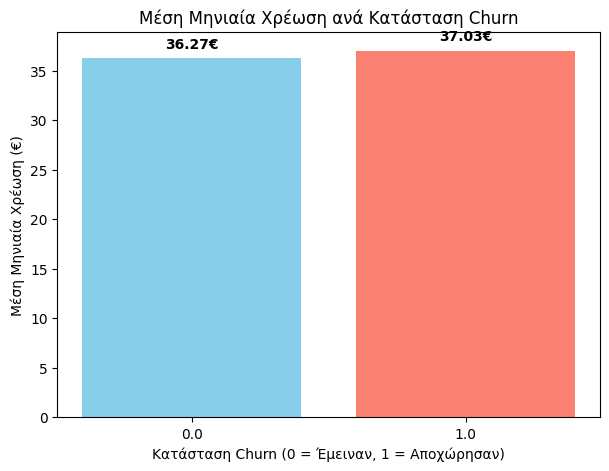

In [ ]:
import matplotlib.pyplot as plt

df_23 = spark.sql(query_231).toPandas()

# Δημιουργία Bar Chart
plt.figure(figsize=(7, 5))
colors = ['skyblue', 'salmon']
plt.bar(df_23['CHURN'].astype(str), df_23['average_monthly_charges'], color=colors)

# Προσθήκη ετικετών και τίτλου
plt.xlabel('Κατάσταση Churn (0 = Έμειναν, 1 = Αποχώρησαν)')
plt.ylabel('Μέση Μηνιαία Χρέωση (€)')
plt.title('Μέση Μηνιαία Χρέωση ανά Κατάσταση Churn')

# Προσθήκη των τιμών πάνω από τις μπάρες για ευκρίνεια
for i, val in enumerate(df_23['average_monthly_charges']):
    plt.text(i, val + 1, f'{val:.2f}€', ha='center', fontweight='bold')

plt.show()

In [ ]:
# 2.3 Churn και μηνιαία χρέωση
print("2.3. Μέση μηνιαία χρέωση ανά κατάσταση Churn και τύπο συμβολαίου:")

query_23 = """
SELECT
    CONTRACT_TYPE,
    CHURN,
    ROUND(AVG(MONTHLY_CHARGES), 2) AS Avg_Monthly_Charges
FROM churn_view
GROUP BY CONTRACT_TYPE, CHURN
ORDER BY CONTRACT_TYPE, CHURN
"""

spark.sql(query_23).show()

2.3. Μέση μηνιαία χρέωση ανά κατάσταση Churn και τύπο συμβολαίου:
+--------------+-----+-------------------+
| CONTRACT_TYPE|CHURN|Avg_Monthly_Charges|
+--------------+-----+-------------------+
|Month-to-month|  0.0|              41.23|
|Month-to-month|  1.0|               38.5|
|      One year|  0.0|              35.26|
|      One year|  1.0|              33.47|
|      Two year|  0.0|              30.05|
|      Two year|  1.0|              28.15|
+--------------+-----+-------------------+



In [ ]:
# 3 Γεωγραφική ανάλυση (Top-5 χώρες με υψηλότερο Churn)
print("3. Top-5 Χώρες με το υψηλότερο ποσοστό churn (τουλάχιστον 100 πελάτες):")
query_3 = """
SELECT
    COUNTRY,
    COUNT(*) AS Customer_Count,
    ROUND(AVG(CHURN) * 100, 2) AS Churn_Percentage
FROM churn_view
GROUP BY COUNTRY
HAVING COUNT(*) >= 100
ORDER BY Churn_Percentage DESC
LIMIT 5
"""
spark.sql(query_3).show()

3. Top-5 Χώρες με το υψηλότερο ποσοστό churn (τουλάχιστον 100 πελάτες):
+-------+--------------+----------------+
|COUNTRY|Customer_Count|Churn_Percentage|
+-------+--------------+----------------+
|     IT|          1003|           40.78|
|     DE|          1198|           37.65|
|     GR|          3732|           37.03|
|     UK|          1560|           36.15|
|     ES|          1050|            36.1|
+-------+--------------+----------------+



In [ ]:
"""
Σχολιασμός αποτελεσμάτων sql με hints:
Η ανάλυση των δεδομένων επιβεβαιώνει σε μεγάλο βαθμό τις αρχικές υποθέσεις (hints) για τη συμπεριφορά των πελατών.
Πρώτον,από τα αποτελέσματα του πρώτου sql ερωτήματος παρατηρούμε ότι οι πελάτες με συμβόλαιο Month-to-month παρουσιάζουν το υψηλότερο ποσοστό αποχώρησης(53.21),
γεγονός που αποδεικνύει ότι η έλλειψη μακροχρόνιας δέσμευσης διευκολύνει το Churn σε σχέση με τους πελάτες που διαθέτουν συμβόλαια του ενός ή δύο χρόνων(20.61 και 13.65 αντίστοιχα).
Από τα αποτελέσματα του δεύτερου ερωτήματος sql προκύπτει ότι όσο αυξάνεται ο αριθμός των υπηρεσιών (NUM_SERVICES), τόσο τείνει να μειώνεται το ποσοστό Churn. Oι πελάτες με 3 ή περισσότερες υπηρεσίες (NUM_SERVICES ≥ 3)
εμφανίζουν σημαντικά χαμηλότερο churn(25.12) σε σχέση με όσους έχουν καμία ή μόνο μία υπηρεσία (43.23 και 47.98 αντίστοιχα), επιβεβαιώνοντας ότι οι πελάτες με 3 ή περισσότερες υπηρεσίες (Internet, Mobile, TV)
είναι πιο "δεμένοι" με την εταιρεία και αποχωρούν δυσκολότερα από εκείνους που έχουν μόνο μία υπηρεσία.
Από τα αποτελέσματα του τρίτου sql ερωτήματος παρατηρούμε ότι η μέση τιμή των MONTHLY_CHARGES είναι υψηλότερη στους πελάτες που αποχώρησαν (Για CHURN=1 το average_monthly_charges=37.03 ενώ για CHURN=0 το average_monthly_charges=36.27) ,
υποδεικνύοντας ότι το κόστος αποτελεί καθοριστικό παράγοντα για την απόφαση ενός πελάτη να διακόψει τη σύνδεσή του.

Στο ερώτημα 2.3 χωρίς την υλοποίηση του προαιρετικού κομματιού και μετά με την υλοποίηση του στο επόμενο κελί παρατηρείται μια ενδιαφέρουσα ανατροπή.
Ενώ συνολικά οι αποχωρήσαντες πελάτες έχουν υψηλότερες μέσες χρεώσεις, εντός των κατηγοριών συμβολαίου(προαιρετικό κομμάτι ανα κατηγορία συμβολαίου) οι πιστοί πελάτες (CHURN=0)
εμφανίζουν συχνά μεγαλύτερο μέσο όρο μηνιαίων χρεώσεων.Αυτό επιβεβαιώνει οι πελάτες με 'πλήρη πακέτα' υπηρεσιών (υψηλότερο κόστος)
τείνουν να παραμένουν στην εταιρεία λόγω της αξίας των συνδυαστικών υπηρεσιών και της μακροχρόνιας δέσμευσης, σε αντίθεση με πελάτες που έχουν μεμονωμένες υπηρεσίες.

Επιπλέον, η γεωγραφική ανάλυση από το ερώτημα τέσσερα ανέδειξε συγκεκριμένες χώρες με αυξημένο κίνδυνο αποχώρησης (IT=40.78, DE=37.65,GR=37.03,UK=36.15,ES=36.1).
Ο συνδυασμός των παραπάνω με τον αριθμό των παραπόνων λειτουργεί ως ισχυρό "σήμα κινδύνου" για την εταιρεία.

Συμπερασματικά, τα "hints" του προβλήματος επιβεβαιώνονται πλήρως από τα δεδομένα.
Η ανάλυση αποκαλύπτει ότι το ρίσκο αποχώρησης δεν καθορίζεται απλώς από το ύψος της χρέωσης αλλά και από τη σχέση κόστους-δέσμευσης.
Παρόλο που οι πιστοί πελάτες (CHURN=0) εμφανίζουν συχνά υψηλότερες μέσες χρεώσεις λόγω της χρήσης πολλαπλών υπηρεσιών,
παραμένουν στην εταιρεία καθώς η αξία του πακέτου και ο τύπος του συμβολαίου λειτουργούν ως ανασταλτικοί παράγοντες.
Η ομάδα υψηλότερου κινδύνου εντοπίζεται στους πελάτες με υψηλές χρεώσεις σε μεμονωμένες υπηρεσίες και μηνιαία συμβόλαια,
όπου η έλλειψη συνδυαστικών παροχών καθιστά την αποχώρηση ευκολότερη.
Η στρατηγική της εταιρείας πρέπει να εστιάσει στην προώθηση πακέτων πολλαπλών υπηρεσιών σε πελάτες με απλές συνδέσεις,
μετατρέποντας το υψηλό κόστος σε αντιληπτή αξία και ενισχύοντας την πιστότητα μέσω μακροχρόνιων δεσμεύσεων.Επίσηςίσως θα έπρεπε να εστιαστεί
στη μετατροπή των μηνιαίων συμβολαίων σε ετήσια και στην παροχή εκπτώσεων σε πελάτες με υψηλές χρεώσεις για την αποτροπή του Churn.

"""

'\nΣχολιασμός αποτελεσμάτων sql με hints:\nΗ ανάλυση των δεδομένων επιβεβαιώνει σε μεγάλο βαθμό τις αρχικές υποθέσεις (hints) για τη συμπεριφορά των πελατών.\nΠρώτον,από τα αποτελέσματα του πρώτου sql ερωτήματος παρατηρούμε ότι οι πελάτες με συμβόλαιο Month-to-month παρουσιάζουν το υψηλότερο ποσοστό αποχώρησης(53.21),\nγεγονός που αποδεικνύει ότι η έλλειψη μακροχρόνιας δέσμευσης διευκολύνει το Churn σε σχέση με τους πελάτες που διαθέτουν συμβόλαια του ενός ή δύο χρόνων(20.61 και 13.65 αντίστοιχα).\nΑπό τα αποτελέσματα του δεύτερου ερωτήματος sql προκύπτει ότι όσο αυξάνεται ο αριθμός των υπηρεσιών (NUM_SERVICES), τόσο τείνει να μειώνεται το ποσοστό Churn. Oι πελάτες με 3 ή περισσότερες υπηρεσίες (NUM_SERVICES ≥ 3)\nεμφανίζουν σημαντικά χαμηλότερο churn(25.12) σε σχέση με όσους έχουν καμία ή μόνο μία υπηρεσία (43.23 και 47.98 αντίστοιχα), επιβεβαιώνοντας ότι οι πελάτες με 3 ή περισσότερες υπηρεσίες (Internet, Mobile, TV)\nείναι πιο "δεμένοι" με την εταιρεία και αποχωρούν δυσκολότερα από 

In [ ]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, OneHotEncoder
from pyspark.ml.regression import DecisionTreeRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Επιλογή Χαρακτηριστικών (Features) και Στόχου (Label)
selected_columns = [
    'AGE', 'TENURE_MONTHS', 'NUM_COMPLAINTS', 'SUPPORT_CALLS',
    'HAS_INTERNET', 'HAS_MOBILE', 'HAS_TV', 'NUM_SERVICES',
    'CONTRACT_TYPE', 'PAYMENT_METHOD', 'COUNTRY', 'MONTHLY_CHARGES'
]

# Δημιουργία νέου DataFrame με τις επιλεγμένες στήλες
df_model = df_final.select(selected_columns)

# Προεπεξεργασία και Pipeline
# StringIndexer για τα κατηγορικά πεδία
indexer_contract = StringIndexer(inputCol="CONTRACT_TYPE", outputCol="CONTRACT_INDEX")
indexer_payment = StringIndexer(inputCol="PAYMENT_METHOD", outputCol="PAYMENT_INDEX")
indexer_country = StringIndexer(inputCol="COUNTRY", outputCol="COUNTRY_INDEX")

# OneHotEncoder για τα indexed πεδία
encoder = OneHotEncoder(
    inputCols=["CONTRACT_INDEX", "PAYMENT_INDEX", "COUNTRY_INDEX"],
    outputCols=["CONTRACT_VEC", "PAYMENT_VEC", "COUNTRY_VEC"]
)

#VectorAssembler: Συνένωση όλων των χαρακτηριστικών σε ένα διάνυσμα "features"
feature_cols = [
    'AGE', 'TENURE_MONTHS', 'NUM_COMPLAINTS', 'SUPPORT_CALLS',
    'HAS_INTERNET', 'HAS_MOBILE', 'HAS_TV', 'NUM_SERVICES',
    'CONTRACT_VEC', 'PAYMENT_VEC', 'COUNTRY_VEC'
]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")

# Ορισμός του DecisionTreeRegressor
dt_regressor = DecisionTreeRegressor(labelCol="MONTHLY_CHARGES", featuresCol="features")

#Δημιουργία του Pipeline
pipeline = Pipeline(stages=[
    indexer_contract,
    indexer_payment,
    indexer_country,
    encoder,
    assembler,
    dt_regressor
])



In [ ]:
#Εκπαίδευση και Αξιολόγηση
# Χωρισμός σε Train (70%) και Test (30%) set
train_data, test_data = df_model.randomSplit([0.7, 0.3], seed=25)

# Εκπαίδευση του μοντέλου
model = pipeline.fit(train_data)

# Παραγωγή προβλέψεων στο test set
predictions = model.transform(test_data)

# Εμφάνιση δείγματος προβλέψεων
print("Δείγμα Προβλέψεων vs Πραγματικών Τιμών:")
predictions.select("MONTHLY_CHARGES", "prediction").show(10)

# Υπολογισμός Μετρικών (RMSE και R2)
evaluator_rmse = RegressionEvaluator(labelCol="MONTHLY_CHARGES", predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol="MONTHLY_CHARGES", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)

print(f"Root Mean Squared Error (RMSE) στο test set: {rmse:.2f}")
print(f"Coefficient of Determination (R2) στο test set: {r2:.2f}")

Δείγμα Προβλέψεων vs Πραγματικών Τιμών:
+---------------+------------------+
|MONTHLY_CHARGES|        prediction|
+---------------+------------------+
|          20.05|20.874141156462592|
|          44.76| 35.48900854361217|
|          55.55| 47.06706884681583|
|          42.51| 39.55160492385313|
|          23.77| 42.50082015306125|
|          54.58| 39.55160492385313|
|          32.14|  29.3736858076564|
|           37.9| 30.86769318181819|
|          54.31| 47.06706884681583|
|          26.31|30.163351113172542|
+---------------+------------------+
only showing top 10 rows
Root Mean Squared Error (RMSE) στο test set: 8.01
Coefficient of Determination (R2) στο test set: 0.50


In [1]:
"""  Τον σχολιασμό των αποτελεσμάτων τoν έχω τοποθετήσει στην αναφορά μου """

'  Τον σχολιασμό των αποτελεσμάτων τoν έχω τοποθετήσει στην αναφορά μου '

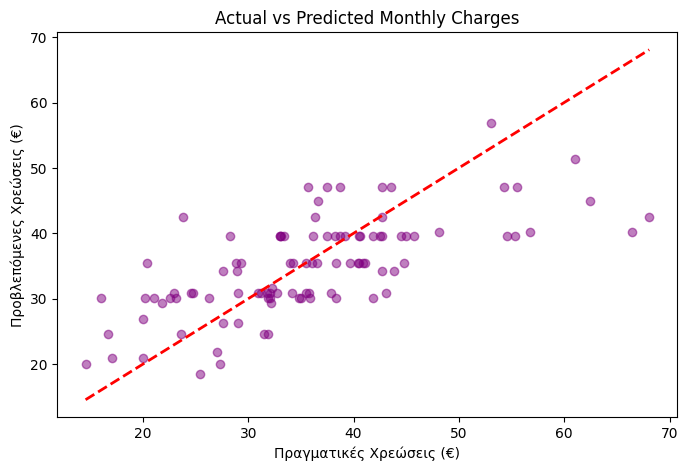

In [ ]:
import matplotlib.pyplot as plt
# Επιλογή ενός δείγματος
sample_data = predictions.select("MONTHLY_CHARGES", "prediction").limit(100).toPandas()

plt.figure(figsize=(8, 5))
plt.scatter(sample_data['MONTHLY_CHARGES'], sample_data['prediction'], alpha=0.5, color='purple')
plt.plot([sample_data['MONTHLY_CHARGES'].min(), sample_data['MONTHLY_CHARGES'].max()],
         [sample_data['MONTHLY_CHARGES'].min(), sample_data['MONTHLY_CHARGES'].max()],
         'r--', lw=2) # Διαγώνιος γραμμή τέλειας πρόβλεψης
plt.xlabel('Πραγματικές Χρεώσεις (€)')
plt.ylabel('Προβλεπόμενες Χρεώσεις (€)')
plt.title('Actual vs Predicted Monthly Charges')
plt.show()